In [2]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
Tesla T4


In [4]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import pydicom

from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

In [5]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)
    break

/kaggle/input


In [7]:
import os
import numpy as np
import pandas as pd
import pydicom

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

In [8]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cuda


In [9]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/vishalmanta
/kaggle/input/datasets/vishalmanta/medical-transformer-benchmark2
/kaggle/input/datasets/vishalmanta/medical-transformer-benchmark
/kaggle/input/datasets/vishalmanta/medical-transformer-benchmark/images
/kaggle/input/datasets/vishalmanta/medical-transformer-benchmark/images/images
/kaggle/input/datasets/vishalmanta/my-saved-models4
/kaggle/input/datasets/vishalmanta/my-saved-models3


In [10]:
DATA_PATH = "/kaggle/input/datasets/vishalmanta/medical-transformer-benchmark"

In [11]:
import os

image_dir = "/kaggle/input/datasets/vishalmanta/medical-transformer-benchmark/images/images"

print("Number of DICOM files:", len(os.listdir(image_dir)))

print(os.listdir(image_dir)[:5])

Number of DICOM files: 26684
['c3b05294-29be-46e4-8a51-96fd211e4ca5.dcm', '6a6ed2c5-d179-4c19-aac7-0d70eb87e024.dcm', '06550cfd-e9d5-415e-bae9-3146329ed9e6.dcm', 'ef9eee29-6bdd-41da-ae40-9473592a9d5c.dcm', 'c5dfc1a7-4669-42ce-af9f-62c3d8322049.dcm']


In [12]:
import pandas as pd

DATA_PATH = "/kaggle/input/datasets/vishalmanta/medical-transformer-benchmark"

labels = pd.read_csv(
    f"{DATA_PATH}/stage_2_train_labels.csv"
)

print(labels.shape)
labels.head()

(30227, 6)


,patientId,x,y,width,height,Target
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,NaN,NaN,NaN,NaN,0
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,NaN,NaN,NaN,NaN,0
2,00322d4d-1c29-4943-afc9-b6754be640eb,NaN,NaN,NaN,NaN,0
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,NaN,NaN,NaN,NaN,0
4,00436515-870c-4b36-a041-de91049b9ab4,264.0,152.0,213.0,379.0,1


In [13]:
classification_labels = (
    labels.groupby('patientId')['Target']
    .max()
    .reset_index()
)

print("Patients:", len(classification_labels))

Patients: 26684


In [14]:
sample_id = classification_labels.iloc[0]['patientId']

sample_path = os.path.join(
    image_dir,
    sample_id + ".dcm"
)

print(sample_path)
print(os.path.exists(sample_path))

/kaggle/input/datasets/vishalmanta/medical-transformer-benchmark/images/images/0004cfab-14fd-4e49-80ba-63a80b6bddd6.dcm
True


In [15]:
train_ids = pd.read_csv("/kaggle/input/datasets/vishalmanta/medical-transformer-benchmark2/train_ids.csv")
val_ids = pd.read_csv("/kaggle/input/datasets/vishalmanta/medical-transformer-benchmark2/val_ids.csv")
test_ids = pd.read_csv("/kaggle/input/datasets/vishalmanta/medical-transformer-benchmark2/test_ids.csv")

In [16]:
train_labels = labels[
    labels['patientId'].isin(train_ids['patientId'])
]

val_labels = labels[
    labels['patientId'].isin(val_ids['patientId'])
]

test_labels = labels[
    labels['patientId'].isin(test_ids['patientId'])
]

In [17]:
train_df = (
    train_labels.groupby('patientId')['Target']
    .max()
    .reset_index()
)

val_df = (
    val_labels.groupby('patientId')['Target']
    .max()
    .reset_index()
)

test_df = (
    test_labels.groupby('patientId')['Target']
    .max()
    .reset_index()
)

In [18]:
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 18678
Validation: 4003
Test: 4003


In [19]:
import os
import pydicom
import numpy as np

from PIL import Image
from torch.utils.data import Dataset

class RSNADataset(Dataset):

    def __init__(self, labels_df, image_dir, transform=None):
        self.labels_df = labels_df
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.labels_df)

    def __getitem__(self, idx):

        patient_id = self.labels_df.iloc[idx]['patientId']

        label = int(
            self.labels_df.iloc[idx]['Target']
        )

        image_path = os.path.join(
            self.image_dir,
            patient_id + ".dcm"
        )

        dicom = pydicom.dcmread(image_path)

        image = dicom.pixel_array.astype(np.float32)

        image = (
            image - image.min()
        ) / (
            image.max() - image.min() + 1e-8
        )

        image = Image.fromarray(
            (image * 255).astype(np.uint8)
        ).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [20]:
print(RSNADataset)

<class '__main__.RSNADataset'>


In [21]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

print("Transform created successfully!")

Transform created successfully!


In [22]:
train_dataset = RSNADataset(
    train_df,
    image_dir,
    transform
)

val_dataset = RSNADataset(
    val_df,
    image_dir,
    transform
)

test_dataset = RSNADataset(
    test_df,
    image_dir,
    transform
)

print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

Train samples: 18678
Val samples: 4003
Test samples: 4003


In [23]:
image, label = train_dataset[0]

print("Image shape:", image.shape)
print("Label:", label)

Image shape: torch.Size([3, 224, 224])
Label: 0


In [24]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size= 32,
    shuffle=False,
    num_workers=2
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 584
Val batches: 126
Test batches: 126


In [25]:
images, labels_batch = next(iter(train_loader))

print(images.shape)
print(labels_batch.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [26]:
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cuda


In [30]:
print(train_loader.dataset.__dict__.keys())

dict_keys(['labels_df', 'image_dir', 'transform'])


In [31]:
print(train_loader.dataset.labels_df.columns)

Index(['patientId', 'Target'], dtype='object')


In [32]:
import pandas as pd

summary = pd.DataFrame({
    "Training": train_loader.dataset.labels_df["Target"].value_counts(),
    "Validation": val_loader.dataset.labels_df["Target"].value_counts(),
    "Testing": test_loader.dataset.labels_df["Target"].value_counts()
})

summary.index = ["Normal (0)", "Pneumonia (1)"]

print(summary)

               Training  Validation  Testing
Normal (0)        14503        3087     3082
Pneumonia (1)      4175         916      921


In [25]:
import torch.nn as nn
from torchvision import models

model = models.resnet50(
    weights="DEFAULT"
)

num_features = model.fc.in_features

model.fc = nn.Linear(
    num_features,
    2
)

model = model.to(device)

print("Model ready")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 203MB/s]


Model ready


In [26]:
criterion = nn.CrossEntropyLoss()

import torch.optim as optim

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4
)

print("Training setup complete")

Training setup complete


In [27]:
print(device)
print(len(train_loader))
print(len(val_loader))
print(len(test_loader))

cuda
584
126
126


In [28]:
import torch

torch.cuda.empty_cache()

print("GPU cache cleared")

GPU cache cleared


In [29]:
best_val_acc = 0.0

num_epochs = 10

for epoch in range(num_epochs):

    model.train()

    train_loss = 0.0

    for batch_idx, (images, labels_batch) in enumerate(train_loader):

        images = images.to(device)
        labels_batch = labels_batch.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels_batch)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        if batch_idx % 50 == 0:

            print(
                f"Epoch {epoch+1}/{num_epochs} | "
                f"Batch {batch_idx}/{len(train_loader)} | "
                f"Loss: {loss.item():.4f}"
            )

    avg_train_loss = train_loss / len(train_loader)

    model.eval()

    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels_batch in val_loader:

            images = images.to(device)
            labels_batch = labels_batch.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels_batch)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels_batch.size(0)

            correct += (predicted == labels_batch).sum().item()

    avg_val_loss = val_loss / len(val_loader)

    val_accuracy = 100 * correct / total

    print("\n" + "=" * 50)
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss : {avg_train_loss:.4f}")
    print(f"Val Loss   : {avg_val_loss:.4f}")
    print(f"Val Acc    : {val_accuracy:.2f}%")
    print("=" * 50)

    if val_accuracy > best_val_acc:

        best_val_acc = val_accuracy

        torch.save(
            {
                'epoch': epoch + 1,
                'val_acc': val_accuracy,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict()
            },
            "/kaggle/working/best_resnet50_new.pth"
        )

        print(
            f"New Best Model Saved! "
            f"Epoch {epoch+1} | "
            f"Val Acc = {val_accuracy:.2f}%"
        )

print(f"\nBest Validation Accuracy = {best_val_acc:.2f}%")

Epoch 1/10 | Batch 0/584 | Loss: 0.7184
Epoch 1/10 | Batch 50/584 | Loss: 0.4171
Epoch 1/10 | Batch 100/584 | Loss: 0.3335
Epoch 1/10 | Batch 150/584 | Loss: 0.4248
Epoch 1/10 | Batch 200/584 | Loss: 0.3768
Epoch 1/10 | Batch 250/584 | Loss: 0.3657
Epoch 1/10 | Batch 300/584 | Loss: 0.4948
Epoch 1/10 | Batch 350/584 | Loss: 0.4154
Epoch 1/10 | Batch 400/584 | Loss: 0.3422
Epoch 1/10 | Batch 450/584 | Loss: 0.2594
Epoch 1/10 | Batch 500/584 | Loss: 0.3871
Epoch 1/10 | Batch 550/584 | Loss: 0.3102

Epoch 1/10
Train Loss : 0.3850
Val Loss   : 0.3756
Val Acc    : 83.16%
New Best Model Saved! Epoch 1 | Val Acc = 83.16%
Epoch 2/10 | Batch 0/584 | Loss: 0.3484
Epoch 2/10 | Batch 50/584 | Loss: 0.2728
Epoch 2/10 | Batch 100/584 | Loss: 0.4123
Epoch 2/10 | Batch 150/584 | Loss: 0.2867
Epoch 2/10 | Batch 200/584 | Loss: 0.2024
Epoch 2/10 | Batch 250/584 | Loss: 0.4871
Epoch 2/10 | Batch 300/584 | Loss: 0.4328
Epoch 2/10 | Batch 350/584 | Loss: 0.3064
Epoch 2/10 | Batch 400/584 | Loss: 0.2313
Epo

In [30]:
checkpoint = torch.load(
    "/kaggle/working/best_resnet50_new.pth"
)

model.load_state_dict(
    checkpoint['model_state_dict']
)

model.eval()

print("Best Epoch:", checkpoint['epoch'])
print("Best Val Acc:", checkpoint['val_acc'])

Best Epoch: 2
Best Val Acc: 84.03697227079691


In [31]:

model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels_batch in test_loader:

        images = images.to(device)
        labels_batch = labels_batch.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels_batch.size(0)

        correct += (
            predicted == labels_batch
        ).sum().item()

test_accuracy = 100 * correct / total

print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 84.56%


In [32]:
torch.save(
    model.state_dict(),
    "/kaggle/working/rsna_resnet50_final_new.pth"
)

In [33]:
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
}, "/kaggle/working/rsna_checkpoint_new.pth")

In [23]:
import torch
import torch.nn as nn
from torchvision import models

# Create ResNet50 architecture
model = models.resnet50(weights=None)

# Replace final layer
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

# Move to device
model = model.to(device)

# Load checkpoint
checkpoint = torch.load(
    "/kaggle/input/datasets/vishalmanta/my-saved-models4/best_resnet50_new.pth",
    map_location=device
)

# Load model weights
model.load_state_dict(
    checkpoint["model_state_dict"]
)

# Evaluation mode
model.eval()

print("ResNet50 loaded successfully!")

# Print validation accuracy
if "val_acc" in checkpoint:
    print(f"Validation Accuracy: {checkpoint['val_acc']:.2f}%")

ResNet50 loaded successfully!
Validation Accuracy: 84.04%


In [24]:
import torch
import torch.nn as nn

from torchvision.models import vit_b_16
from torchvision.models import ViT_B_16_Weights

weights = ViT_B_16_Weights.DEFAULT

vit_model = vit_b_16(weights=weights)

num_features = vit_model.heads.head.in_features

vit_model.heads.head = nn.Linear(
    num_features,
    2
)

vit_model = vit_model.to(device)

print("ViT-B/16 Ready!")

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 222MB/s]  


ViT-B/16 Ready!


In [39]:
criterion = nn.CrossEntropyLoss()

In [40]:
import torch.optim as optim

optimizer = optim.Adam(
    vit_model.parameters(),
    lr=1e-4
)

In [ ]:
print(vit_model)

In [47]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    vit_model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

best_val_acc = 0.0

num_epochs = 10

for epoch in range(num_epochs):

    vit_model.train()

    train_loss = 0.0

    for batch_idx, (images, labels_batch) in enumerate(train_loader):

        images = images.to(device)
        labels_batch = labels_batch.to(device)

        outputs = vit_model(images)

        loss = criterion(
            outputs,
            labels_batch
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        if batch_idx % 50 == 0:

            print(
                f"Epoch {epoch+1}/{num_epochs} | "
                f"Batch {batch_idx}/{len(train_loader)} | "
                f"Loss {loss.item():.4f}"
            )

    avg_train_loss = (
        train_loss / len(train_loader)
    )

    vit_model.eval()

    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels_batch in val_loader:

            images = images.to(device)
            labels_batch = labels_batch.to(device)

            outputs = vit_model(images)

            loss = criterion(
                outputs,
                labels_batch
            )

            val_loss += loss.item()

            _, predicted = torch.max(
                outputs,
                1
            )

            total += labels_batch.size(0)

            correct += (
                predicted == labels_batch
            ).sum().item()

    avg_val_loss = (
        val_loss / len(val_loader)
    )

    val_accuracy = (
        100 * correct / total
    )

    print("\n" + "=" * 50)
    print(f"Epoch {epoch+1}")
    print(f"Train Loss : {avg_train_loss:.4f}")
    print(f"Val Loss   : {avg_val_loss:.4f}")
    print(f"Val Acc    : {val_accuracy:.2f}%")
    print("=" * 50)

    if val_accuracy > best_val_acc:

        best_val_acc = val_accuracy

        torch.save(
            {
                "epoch": epoch + 1,
                "val_acc": val_accuracy,
                "model_state_dict": vit_model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict()
            },
            "/kaggle/working/best_vit_b_16.pth"
        )

        print(
            f"New Best ViT Saved! "
            f"Val Acc = {val_accuracy:.2f}%"
        )

print(
    f"\nBest Validation Accuracy = "
    f"{best_val_acc:.2f}%"
)

Epoch 1/10 | Batch 0/584 | Loss 0.1664
Epoch 1/10 | Batch 50/584 | Loss 0.1353
Epoch 1/10 | Batch 100/584 | Loss 0.2895
Epoch 1/10 | Batch 150/584 | Loss 0.2826
Epoch 1/10 | Batch 200/584 | Loss 0.1616
Epoch 1/10 | Batch 250/584 | Loss 0.2868
Epoch 1/10 | Batch 300/584 | Loss 0.3242
Epoch 1/10 | Batch 350/584 | Loss 0.3030
Epoch 1/10 | Batch 400/584 | Loss 0.4791
Epoch 1/10 | Batch 450/584 | Loss 0.1567
Epoch 1/10 | Batch 500/584 | Loss 0.2848
Epoch 1/10 | Batch 550/584 | Loss 0.2744

Epoch 1
Train Loss : 0.3195
Val Loss   : 0.4295
Val Acc    : 81.06%
New Best ViT Saved! Val Acc = 81.06%
Epoch 2/10 | Batch 0/584 | Loss 0.1519
Epoch 2/10 | Batch 50/584 | Loss 0.4325
Epoch 2/10 | Batch 100/584 | Loss 0.3236
Epoch 2/10 | Batch 150/584 | Loss 0.1904
Epoch 2/10 | Batch 200/584 | Loss 0.3441
Epoch 2/10 | Batch 250/584 | Loss 0.1915
Epoch 2/10 | Batch 300/584 | Loss 0.3163
Epoch 2/10 | Batch 350/584 | Loss 0.3963
Epoch 2/10 | Batch 400/584 | Loss 0.2892
Epoch 2/10 | Batch 450/584 | Loss 0.282

In [49]:

model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels_batch in test_loader:

        images = images.to(device)
        labels_batch = labels_batch.to(device)

        outputs = vit_model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels_batch.size(0)

        correct += (
            predicted == labels_batch
        ).sum().item()

test_accuracy = 100 * correct / total

print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 81.14%


In [50]:
torch.save(
    vit_model.state_dict(),
    "/kaggle/working/vit_b16_rsna_weights.pth"
)

print("ViT weights saved!")

ViT weights saved!


In [26]:
import torch
import torch.nn as nn
from torchvision import models

vit_model = models.vit_b_16(weights=None)

num_features = vit_model.heads.head.in_features

vit_model.heads.head = nn.Linear(
    num_features,
    2
)

vit_model = vit_model.to(device)

In [27]:
checkpoint = torch.load(
    "/kaggle/input/datasets/vishalmanta/my-saved-models3/best_vit_b_16.pth",
    map_location=device
)

vit_model.load_state_dict(
    checkpoint["model_state_dict"]
)

vit_model.eval()

print("Loaded ViT")
print("Validation Accuracy:", checkpoint["val_acc"])

Loaded ViT
Validation Accuracy: 81.413939545341


In [29]:
import numpy as np

def compute_ece(probs, labels, n_bins=10):

    probs = np.array(probs)
    labels = np.array(labels)

    bin_boundaries = np.linspace(
        0,
        1,
        n_bins + 1
    )

    ece = 0.0

    for i in range(n_bins):

        lower = bin_boundaries[i]
        upper = bin_boundaries[i + 1]

        mask = (
            (probs > lower) &
            (probs <= upper)
        )

        if np.sum(mask) > 0:

            accuracy = np.mean(
                labels[mask]
            )

            confidence = np.mean(
                probs[mask]
            )

            ece += (
                np.sum(mask) /
                len(probs)
            ) * abs(
                accuracy -
                confidence
            )

    return ece

In [30]:
resnet_labels = []
resnet_preds = []
resnet_probs = []

model.eval()   # ResNet50 model

with torch.no_grad():

    for images, labels_batch in test_loader:

        images = images.to(device)
        labels_batch = labels_batch.to(device)

        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)[:, 1]

        preds = torch.argmax(outputs, dim=1)

        resnet_labels.extend(
            labels_batch.cpu().numpy()
        )

        resnet_preds.extend(
            preds.cpu().numpy()
        )

        resnet_probs.extend(
            probs.cpu().numpy()
        )

print("ResNet predictions collected.")

ResNet predictions collected.


In [32]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    brier_score_loss,
    confusion_matrix,
    balanced_accuracy_score
)

resnet_acc = accuracy_score(
    resnet_labels,
    resnet_preds
)

resnet_precision = precision_score(
    resnet_labels,
    resnet_preds
)

resnet_recall = recall_score(
    resnet_labels,
    resnet_preds
)

resnet_f1 = f1_score(
    resnet_labels,
    resnet_preds
)

resnet_auc = roc_auc_score(
    resnet_labels,
    resnet_probs
)

resnet_brier = brier_score_loss(
    resnet_labels,
    resnet_probs
)

ece_resnet = compute_ece(
    resnet_probs,
    resnet_labels
)

resnet_cm = confusion_matrix(
    resnet_labels,
    resnet_preds
)

tn, fp, fn, tp = resnet_cm.ravel()

resnet_specificity = tn / (tn + fp)

resnet_balanced_acc = balanced_accuracy_score(
    resnet_labels,
    resnet_preds
)

print("===== ResNet50 =====")

print("Accuracy :", resnet_acc)
print("Precision:", resnet_precision)
print("Recall   :", resnet_recall)
print("Specificity :", resnet_specificity)
print("F1 Score :", resnet_f1)
print("ROC-AUC  :", resnet_auc)
print("Brier    :", resnet_brier)
print("ECE      :", ece_resnet)
print("Balanced Accuracy :", resnet_balanced_acc)

print("\nConfusion Matrix")
print(resnet_cm)

===== ResNet50 =====
Accuracy : 0.8456157881588808
Precision: 0.7285067873303167
Recall   : 0.5244299674267101
Specificity : 0.9415963659961064
F1 Score : 0.6098484848484849
ROC-AUC  : 0.8787460516423687
Brier    : 0.11234127830824285
ECE      : 0.03305302025406414
Balanced Accuracy : 0.7330131667114083

Confusion Matrix
[[2902  180]
 [ 438  483]]


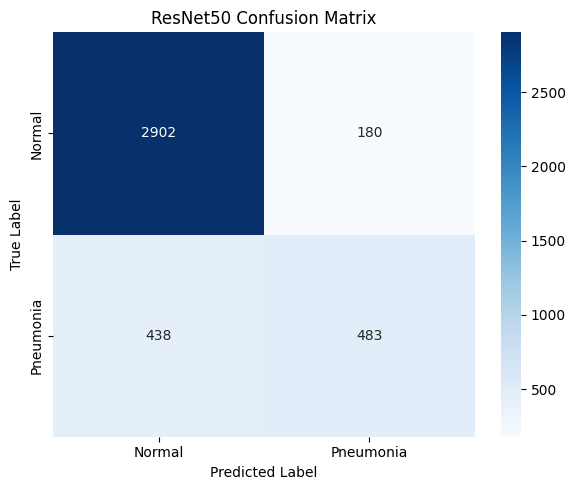

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    resnet_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Pneumonia"],
    yticklabels=["Normal", "Pneumonia"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("ResNet50 Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "/kaggle/working/resnet_confusion.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

plt.close()

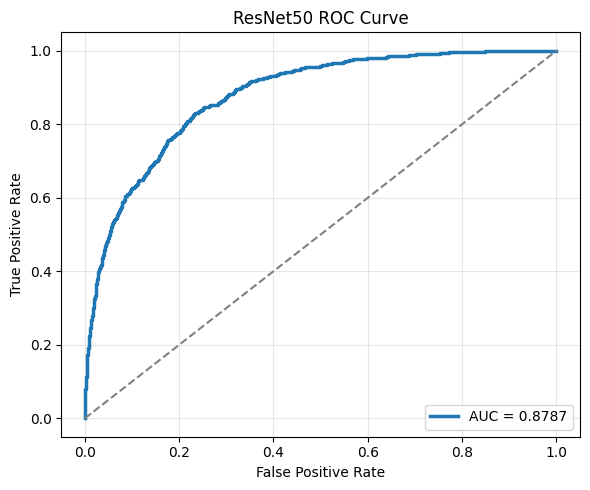

In [35]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(
    resnet_labels,
    resnet_probs
)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    linewidth=2.5,
    label=f"AUC = {resnet_auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    '--',
    color='gray'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ResNet50 ROC Curve")
plt.legend(loc="lower right")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/resnet_roc.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

plt.close()

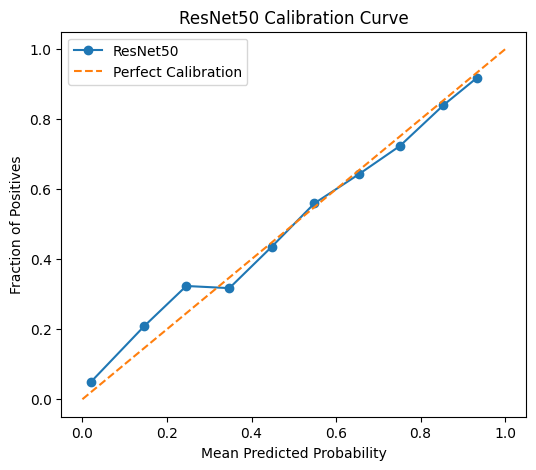

In [184]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(
    resnet_labels,
    resnet_probs,
    n_bins=10
)

plt.figure(figsize=(6,5))

plt.plot(
    prob_pred,
    prob_true,
    marker='o',
    label='ResNet50'
)

plt.plot(
    [0,1],
    [0,1],
    '--',
    label='Perfect Calibration'
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("ResNet50 Calibration Curve")
plt.legend()
plt.savefig(
    "/kaggle/working/calibration_curve_resnet.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [137]:
import pandas as pd

resnet_results = pd.DataFrame({
    "Accuracy": [resnet_acc],
    "Precision": [resnet_precision],
    "Recall": [resnet_recall],
    "Specificity": [resnet_specificity],
    "F1": [resnet_f1],
    "ROC_AUC": [resnet_auc],
    "Balanced_Accuracy": [resnet_balanced_acc],
    "Brier": [resnet_brier],
    "ECE": [ece_resnet]
})

resnet_results.to_csv(
    "/kaggle/working/resnet_results_new.csv",
    index=False
)

print(resnet_results)
print("ResNet results saved successfully!")

   Accuracy  Precision   Recall  Specificity        F1   ROC_AUC  \
0  0.845616   0.728507  0.52443     0.941596  0.609848  0.878746   

   Balanced_Accuracy     Brier       ECE  
0           0.733013  0.112341  0.033053  
ResNet results saved successfully!


In [36]:
vit_labels = []
vit_preds = []
vit_probs = []

vit_model.eval()

with torch.no_grad():

    for images, labels_batch in test_loader:

        images = images.to(device)
        labels_batch = labels_batch.to(device)

        outputs = vit_model(images)

        probs = torch.softmax(
            outputs,
            dim=1
        )[:, 1]

        preds = torch.argmax(
            outputs,
            dim=1
        )

        vit_labels.extend(
            labels_batch.cpu().numpy()
        )

        vit_preds.extend(
            preds.cpu().numpy()
        )

        vit_probs.extend(
            probs.cpu().numpy()
        )

print("Prediction collection completed")

Prediction collection completed


In [37]:
import numpy as np

def compute_ece(probs, labels, n_bins=10):

    probs = np.array(probs)
    labels = np.array(labels)

    bin_boundaries = np.linspace(
        0,
        1,
        n_bins + 1
    )

    ece = 0.0

    for i in range(n_bins):

        lower = bin_boundaries[i]
        upper = bin_boundaries[i + 1]

        mask = (
            (probs > lower) &
            (probs <= upper)
        )

        if np.sum(mask) > 0:

            accuracy = np.mean(
                labels[mask]
            )

            confidence = np.mean(
                probs[mask]
            )

            ece += (
                np.sum(mask) /
                len(probs)
            ) * abs(
                accuracy -
                confidence
            )

    return ece

In [38]:

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    brier_score_loss,
    confusion_matrix,
    balanced_accuracy_score
)

vit_acc = accuracy_score(
    vit_labels,
    vit_preds
)

vit_precision = precision_score(
    vit_labels,
    vit_preds
)

vit_recall = recall_score(
    vit_labels,
    vit_preds
)

vit_f1 = f1_score(
    vit_labels,
    vit_preds
)
vit_auc = roc_auc_score(
    vit_labels,
    vit_probs
)

vit_brier = brier_score_loss(
    vit_labels,
    vit_probs
)

ece_vit = compute_ece(
    vit_probs,
    vit_labels
)

vit_cm = confusion_matrix(
    vit_labels,
    vit_preds
)

tn, fp, fn, tp = vit_cm.ravel()

vit_specificity = tn / (tn + fp)

vit_balanced_acc = balanced_accuracy_score(
    vit_labels,
    vit_preds
)

print("===== ViT-B16 Results =====")

print("Accuracy :", vit_acc)
print("Precision:", vit_precision)
print("Recall   :", vit_recall)
print("Specificity :", vit_specificity)
print("F1 Score :", vit_f1)
print("ROC-AUC  :", vit_auc)
print("Brier    :", vit_brier)
print("ECE      :", ece_vit)
print("Balanced Accuracy :", vit_balanced_acc)

print("\nConfusion Matrix")
print(vit_cm)

===== ViT-B16 Results =====
Accuracy : 0.8113914564076943
Precision: 0.6397306397306397
Recall   : 0.41259500542888167
Specificity : 0.9305645684620376
F1 Score : 0.5016501650165016
ROC-AUC  : 0.8448678572862918
Brier    : 0.13625487069229814
ECE      : 0.08174774077514574
Balanced Accuracy : 0.6715797869454596

Confusion Matrix
[[2868  214]
 [ 541  380]]


In [39]:
from sklearn.metrics import confusion_matrix

vit_cm = confusion_matrix(
    vit_labels,
    vit_preds
)

print(vit_cm)

[[2868  214]
 [ 541  380]]


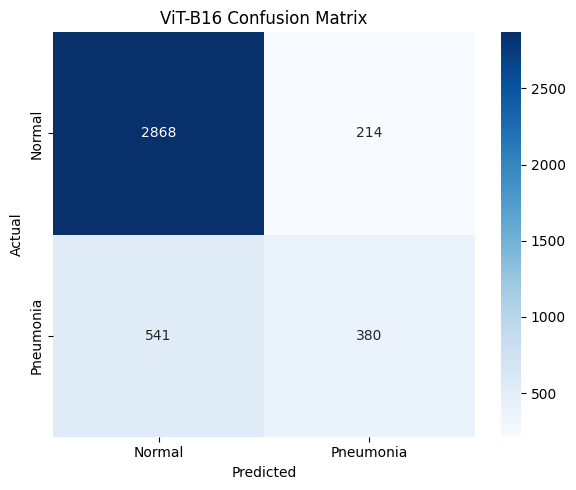

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    vit_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Pneumonia"],
    yticklabels=["Normal", "Pneumonia"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ViT-B16 Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "/kaggle/working/vit_confusion.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

plt.close()

In [42]:
from sklearn.metrics import roc_auc_score

vit_auc = roc_auc_score(
    vit_labels,
    vit_probs
)

print(vit_auc)

0.8448678572862918


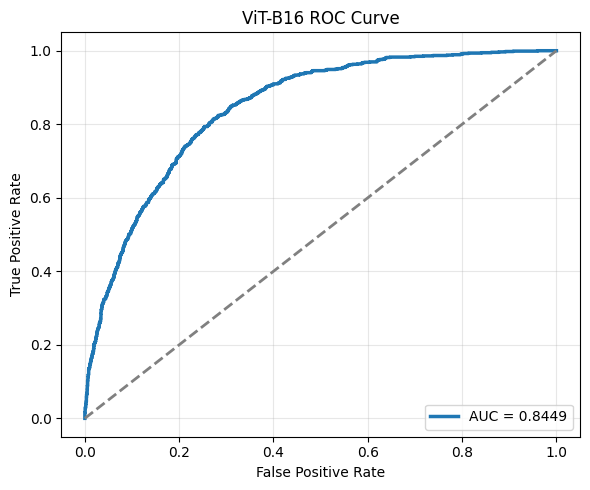

In [43]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(
    vit_labels,
    vit_probs
)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    linewidth=2.5,
    label=f"AUC = {vit_auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    "--",
    color="gray",
    linewidth=2
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ViT-B16 ROC Curve")

plt.legend(loc="lower right")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/vit_roc.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

plt.close()

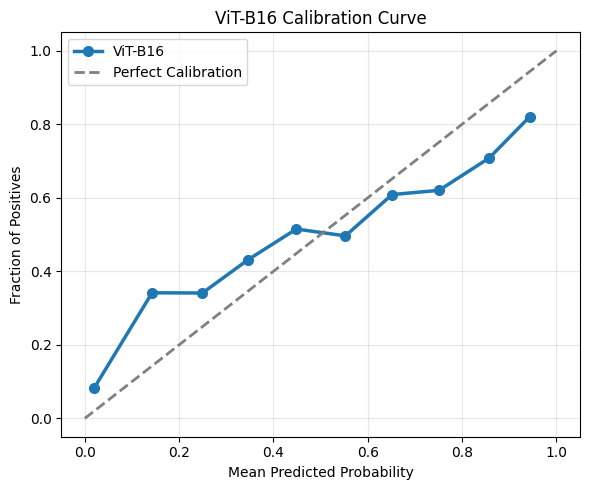

In [44]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(
    vit_labels,
    vit_probs,
    n_bins=10
)

plt.figure(figsize=(6,5))

plt.plot(
    prob_pred,
    prob_true,
    marker='o',
    linewidth=2.5,
    markersize=7,
    label='ViT-B16'
)

plt.plot(
    [0,1],
    [0,1],
    '--',
    color='gray',
    linewidth=2,
    label='Perfect Calibration'
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("ViT-B16 Calibration Curve")

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.savefig(
    "/kaggle/working/calibration_curve_vit.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

plt.close()

In [52]:
from sklearn.metrics import accuracy_score

vit_acc = accuracy_score(
    vit_labels,
    vit_preds
)

print(vit_acc)

0.8113914564076943


In [53]:
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    brier_score_loss,
    confusion_matrix,
    balanced_accuracy_score
)

vit_acc = accuracy_score(
    vit_labels,
    vit_preds
)

vit_precision = precision_score(
    vit_labels,
    vit_preds
)

vit_recall = recall_score(
     vit_labels,
    vit_preds
)

vit_f1 = f1_score(
    vit_labels,
    vit_preds
)
vit_auc = roc_auc_score(
    vit_labels,
    vit_probs
)

vit_brier = brier_score_loss(
    vit_labels,
    vit_probs
)

ece_vit = compute_ece(
    vit_probs,
    vit_labels
)

vit_cm = confusion_matrix(
    vit_labels,
    vit_preds
)
tn, fp, fn, tp = vit_cm.ravel()

vit_specificity = tn / (tn + fp)

vit_balanced_acc = balanced_accuracy_score(
    vit_labels,
    vit_preds
)


vit_results = pd.DataFrame({
    "Accuracy":[vit_acc],
    "Precision":[vit_precision],
    "Recall":[vit_recall],
    "Specificity":[vit_specificity],
    "F1":[vit_f1],
    "ROC_AUC":[vit_auc],
    "Balanced_Accuracy":[vit_balanced_acc],
    "Brier":[vit_brier],
    "ECE":[ece_vit]
})

vit_results.to_csv(
    "/kaggle/working/vit_b16_results.csv",
    index=False
)

print("ViT results saved successfully")

ViT results saved successfully


In [54]:
import pandas as pd

comparison = pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "Specificity",
        "F1 Score",
        "ROC-AUC",
        "Balanced Accuracy",
        "Brier Score",
        "ECE"
    ],

    "ResNet50":[
        resnet_acc,
        resnet_precision,
        resnet_recall,
        resnet_specificity,
        resnet_f1,
        resnet_auc,
        resnet_balanced_acc,
        resnet_brier,
        ece_resnet
    ],

    "ViT-B16":[
        vit_acc,
        vit_precision,
        vit_recall,
        vit_specificity,
        vit_f1,
        vit_auc,
        vit_balanced_acc,
        vit_brier,
        ece_vit
    ]
})

comparison

,Metric,ResNet50,ViT-B16
0,Accuracy,0.845616,0.811391
1,Precision,0.728507,0.639731
2,Recall,0.524430,0.412595
3,Specificity,0.941596,0.930565
4,F1 Score,0.609848,0.501650
5,ROC-AUC,0.878746,0.844868
6,Balanced Accuracy,0.733013,0.671580
7,Brier Score,0.112341,0.136255
8,ECE,0.033053,0.081748


In [55]:
comparison.to_csv(
    "/kaggle/working/model_comparison.csv",
    index=False
)

print("Saved!")

Saved!


In [138]:
resnet_params = sum(
    p.numel()
    for p in model.parameters()
)

print(
    f"ResNet50 Parameters: {resnet_params:,}"
)

ResNet50 Parameters: 23,512,130


In [139]:
vit_params = sum(
    p.numel()
    for p in vit_model.parameters()
)

print(
    f"ViT-B16 Parameters: {vit_params:,}"
)

ViT-B16 Parameters: 85,800,194


In [58]:
import time

start = time.time()

model.eval()

with torch.no_grad():

    for images, _ in test_loader:

        images = images.to(device)

        _ = model(images)

end = time.time()

print(
    "ResNet50 Inference Time:",
    end - start,
    "seconds"
)

ResNet50 Inference Time: 38.56906747817993 seconds


In [59]:
import time

start = time.time()

with torch.no_grad():

    for images, _ in test_loader:

        images = images.to(device)

        _ = vit_model(images)

end = time.time()

print(
    "ViT B_16 Inference Time:",
    end - start,
    "seconds"
)

ViT B_16 Inference Time: 55.604267835617065 seconds


In [60]:
import pandas as pd

print("===== RESNET =====")
print(pd.read_csv("/kaggle/working/resnet_results_new.csv"))

print("\n===== VIT =====")
print(pd.read_csv("/kaggle/working/vit_b16_results.csv"))

print("\n===== COMPARISON =====")
print(pd.read_csv("/kaggle/working/model_comparison.csv"))

===== RESNET =====
   Accuracy  Precision   Recall  Specificity        F1   ROC_AUC  \
0  0.845616   0.728507  0.52443     0.941596  0.609848  0.878746   

   Balanced_Accuracy     Brier       ECE  
0           0.733013  0.112341  0.033053  

===== VIT =====
   Accuracy  Precision    Recall  Specificity       F1   ROC_AUC  \
0  0.811391   0.639731  0.412595     0.930565  0.50165  0.844868   

   Balanced_Accuracy     Brier       ECE  
0            0.67158  0.136255  0.081748  

===== COMPARISON =====
              Metric  ResNet50   ViT-B16
0           Accuracy  0.845616  0.811391
1          Precision  0.728507  0.639731
2             Recall  0.524430  0.412595
3        Specificity  0.941596  0.930565
4           F1 Score  0.609848  0.501650
5            ROC-AUC  0.878746  0.844868
6  Balanced Accuracy  0.733013  0.671580
7        Brier Score  0.112341  0.136255
8                ECE  0.033053  0.081748


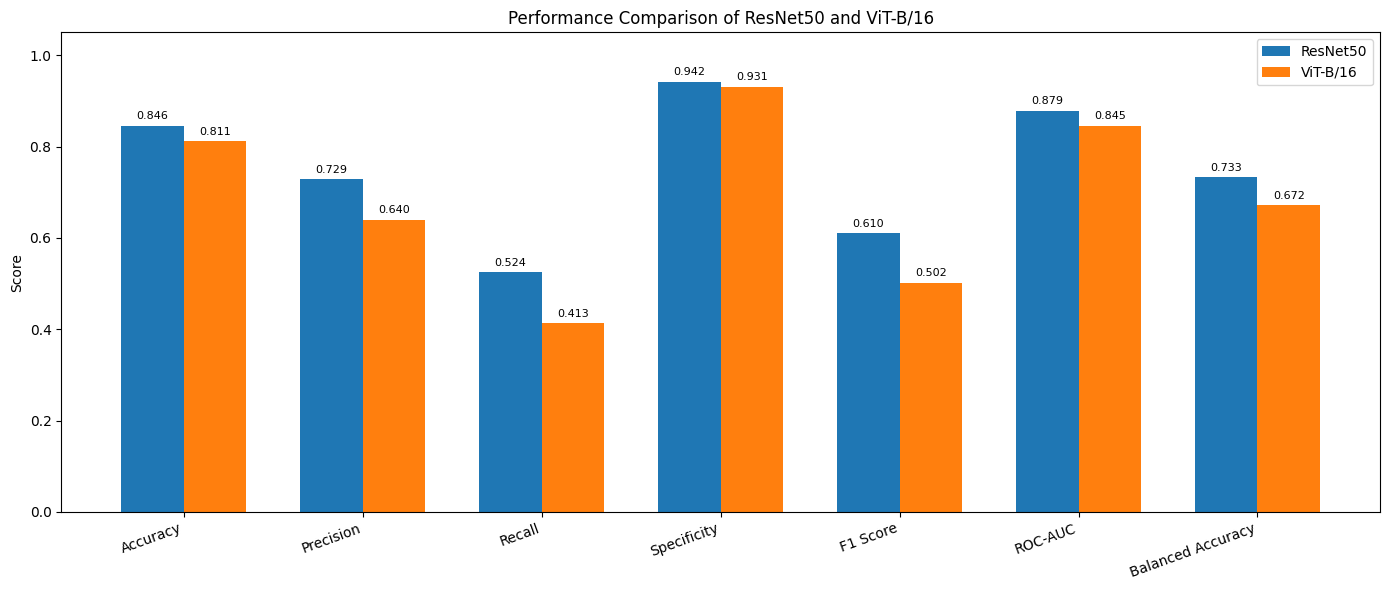

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read comparison file
comparison = pd.read_csv("/kaggle/working/model_comparison.csv")

# Performance metrics
performance = comparison[
    comparison["Metric"].isin([
        "Accuracy",
        "Precision",
        "Recall",
        "Specificity",
        "F1 Score",
        "ROC-AUC",
        "Balanced Accuracy"
    ])
]

metrics = performance["Metric"].tolist()
resnet = performance["ResNet50"].values
vit = performance["ViT-B16"].values

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(14,6))

bars1 = plt.bar(
    x - width/2,
    resnet,
    width,
    label="ResNet50"
)

bars2 = plt.bar(
    x + width/2,
    vit,
    width,
    label="ViT-B/16"
)

plt.xticks(
    x,
    metrics,
    rotation=20,
    ha="right"
)

plt.ylabel("Score")
plt.ylim(0, 1.05)

plt.title("Performance Comparison of ResNet50 and ViT-B/16")

plt.legend()

# Add values above bars
for bar in bars1:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

for bar in bars2:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()

plt.savefig(
    "/kaggle/working/performance_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

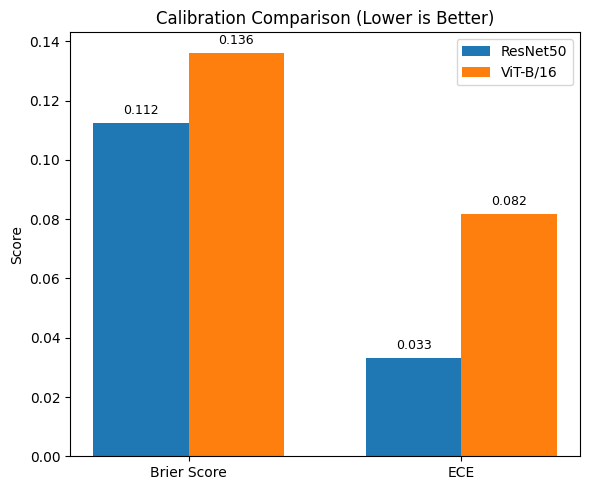

In [140]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

comparison = pd.read_csv("/kaggle/working/model_comparison.csv")

calibration = comparison[
    comparison["Metric"].isin([
        "Brier Score",
        "ECE"
    ])
]

metrics = calibration["Metric"]

resnet = calibration["ResNet50"]

vit = calibration["ViT-B16"]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(6,5))

bars1 = plt.bar(
    x-width/2,
    resnet,
    width,
    label="ResNet50"
)

bars2 = plt.bar(
    x+width/2,
    vit,
    width,
    label="ViT-B/16"
)

plt.xticks(
    x,
    metrics
)

plt.ylabel("Score")

plt.title("Calibration Comparison (Lower is Better)")

plt.legend()

for bar in bars1:
    h = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        h+0.003,
        f"{h:.3f}",
        ha="center",
        fontsize=9
    )

for bar in bars2:
    h = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        h+0.003,
        f"{h:.3f}",
        ha="center",
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    "/kaggle/working/calibration_metrics_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [63]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 89.3 MB/s eta 0:00:00:00:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 95.0 MB/s eta 0:00:00:00:010:01
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=1d68f3c7ad3dfda85c2b8beed364b0e7651410290214cb166a8bd7eae7227081
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.

In [126]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

In [141]:
target_layers = [model.layer4[-1]]

In [142]:
images, labels = next(iter(test_loader))

image = images[0].unsqueeze(0).to(device)

label = labels[0]

print("True Label:", label.item())

True Label: 1


In [143]:
from collections import Counter

print("Prediction counts:")
print(Counter(resnet_preds))

print("\nTrue label counts:")
print(Counter(resnet_labels))

Prediction counts:
Counter({np.int64(0): 3340, np.int64(1): 663})

True label counts:
Counter({np.int64(0): 3082, np.int64(1): 921})


In [144]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(resnet_labels, resnet_preds)
print(cm)

[[2902  180]
 [ 438  483]]


In [145]:
# Correct Normal
normal_idx = next(
    i for i in range(len(resnet_labels))
    if resnet_labels[i] == 0 and resnet_preds[i] == 0
)

# Correct Pneumonia
pneumonia_idx = next(
    i for i in range(len(resnet_labels))
    if resnet_labels[i] == 1 and resnet_preds[i] == 1
)

# Misclassified
misclassified_idx = next(
    i for i in range(len(resnet_labels))
    if resnet_labels[i] != resnet_preds[i]
)

print("Normal:", normal_idx)
print("Pneumonia:", pneumonia_idx)
print("Misclassified:", misclassified_idx)

Normal: 1
Pneumonia: 0
Misclassified: 6


In [71]:
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

target_layers = [model.layer4[-1]]

cam = GradCAM(
    model=model,
    target_layers=target_layers
)

def generate_resnet_gradcam(index, title, save_name):

    image, label = test_loader.dataset[index]

    input_tensor = image.unsqueeze(0).to(device)

    grayscale_cam = cam(
        input_tensor=input_tensor
    )[0]

    rgb_img = image.permute(
        1,
        2,
        0
    ).cpu().numpy()

    rgb_img = (
        rgb_img - rgb_img.min()
    ) / (
        rgb_img.max() - rgb_img.min()
    )

    visualization = show_cam_on_image(
        rgb_img,
        grayscale_cam,
        use_rgb=True
    )

    plt.figure(figsize=(6,6))

    plt.imshow(visualization)

    plt.axis("off")

    plt.title(title)

    plt.savefig(
        f"/kaggle/working/{save_name}",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

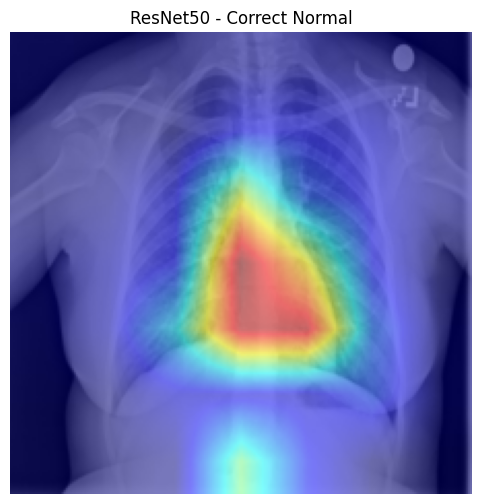

In [72]:
generate_resnet_gradcam(
    normal_idx,
    "ResNet50 - Correct Normal",
    "resnet_gradcam_normal.png"
)

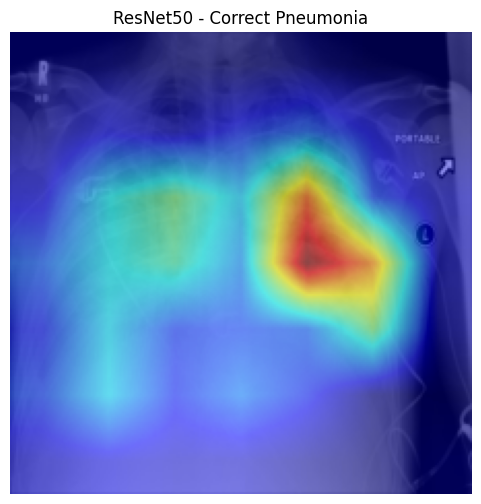

In [73]:
generate_resnet_gradcam(
    pneumonia_idx,
    "ResNet50 - Correct Pneumonia",
    "resnet_gradcam_pneumonia.png"
)

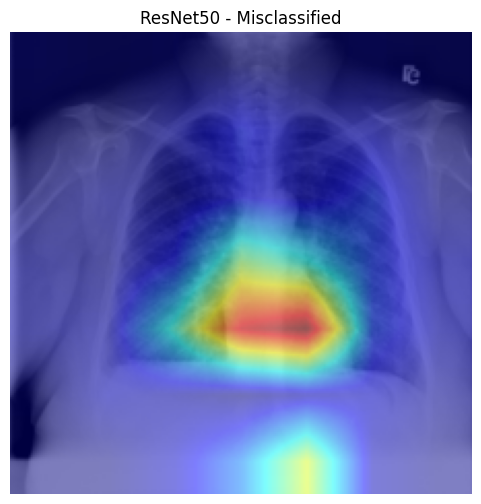

In [74]:
generate_resnet_gradcam(
    misclassified_idx,
    "ResNet50 - Misclassified",
    "resnet_gradcam_misclassified.png"
)

In [75]:
def reshape_transform(tensor, height=14, width=14):
    # Remove CLS token
    tensor = tensor[:, 1:, :]

    result = tensor.reshape(
        tensor.size(0),
        height,
        width,
        tensor.size(2)
    )

    result = result.permute(
        0,
        3,
        1,
        2
    )

    return result

In [76]:
target_layers = [
    vit_model.encoder.layers.encoder_layer_11.ln_1
]

In [77]:
cam = GradCAM(
    model=vit_model,
    target_layers=target_layers,
    reshape_transform=reshape_transform
)

In [78]:
def generate_vit_gradcam(index, title, save_name):

    image, label = test_loader.dataset[index]

    input_tensor = image.unsqueeze(0).to(device)

    grayscale_cam = cam(
        input_tensor=input_tensor
    )[0]

    rgb_img = image.permute(
        1,
        2,
        0
    ).cpu().numpy()

    rgb_img = (
        rgb_img - rgb_img.min()
    ) / (
        rgb_img.max() - rgb_img.min()
    )

    visualization = show_cam_on_image(
        rgb_img,
        grayscale_cam,
        use_rgb=True
    )

    plt.figure(figsize=(6,6))

    plt.imshow(visualization)

    plt.axis("off")

    plt.title(title)

    plt.savefig(
        f"/kaggle/working/{save_name}",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

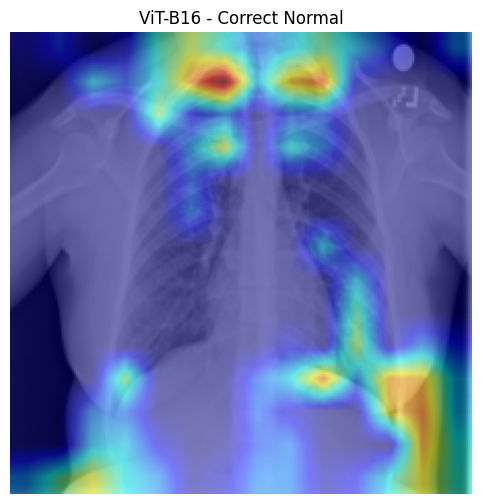

In [79]:
generate_vit_gradcam(
    normal_idx,
    "ViT-B16 - Correct Normal",
    "vit_gradcam_normal.png"
)

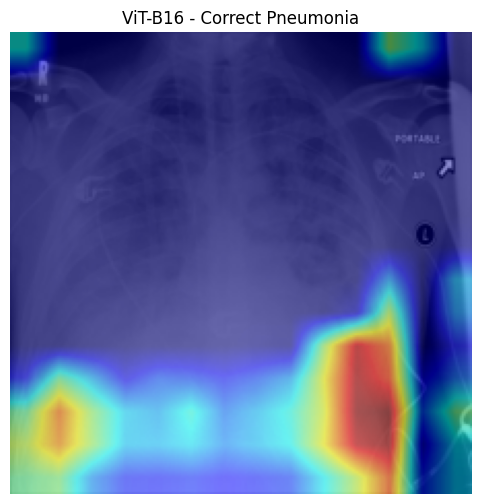

In [80]:
generate_vit_gradcam(
    pneumonia_idx,
    "ViT-B16 - Correct Pneumonia",
    "vit_gradcam_pneumonia.png"
)

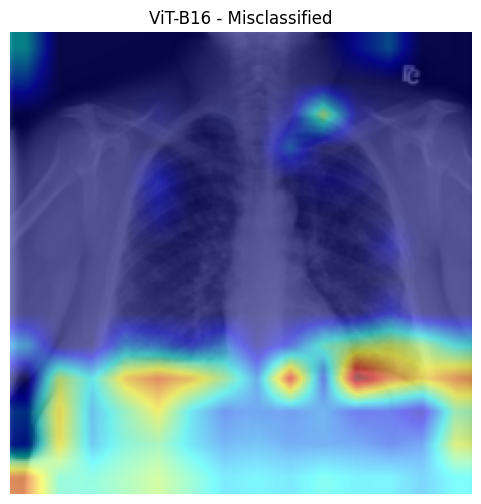

In [81]:
generate_vit_gradcam(
    misclassified_idx,
    "ViT-B16 - Misclassified",
    "vit_gradcam_misclassified.png"
)

In [58]:
from torchvision import transforms

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [59]:
clean_dataset = RSNADataset(
    test_df,
    image_dir="/kaggle/input/datasets/vishalmanta/medical-transformer-benchmark/images/images",
    transform=test_transform
)

clean_loader = DataLoader(
    clean_dataset,
    batch_size=32,
    shuffle=False
)

In [60]:
from torchvision import transforms
import torch

class AddGaussianNoise(object):

    def __init__(self, mean=0., std=0.1):
        self.std = std
        self.mean = mean

    def __call__(self, tensor):

        return torch.clamp(
            tensor +
            torch.randn_like(tensor) * self.std +
            self.mean,
            0,
            1
        )

In [61]:
# Stronger Gaussian Noise
noise_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    AddGaussianNoise(std=0.08),      
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [62]:
# Stronger Blur
blur_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.GaussianBlur(
        kernel_size=7,
        sigma=(2.0,2.0)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [63]:
# Stronger Brightness
brightness_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ColorJitter(
        brightness=0.5
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [64]:
import pandas as pd

labels_df = pd.read_csv(
    "/kaggle/input/datasets/vishalmanta/medical-transformer-benchmark/stage_2_train_labels.csv"
)

print(labels_df.head())
print(labels_df.columns)

                              patientId      x      y  width  height  Target
0  0004cfab-14fd-4e49-80ba-63a80b6bddd6    NaN    NaN    NaN     NaN       0
1  00313ee0-9eaa-42f4-b0ab-c148ed3241cd    NaN    NaN    NaN     NaN       0
2  00322d4d-1c29-4943-afc9-b6754be640eb    NaN    NaN    NaN     NaN       0
3  003d8fa0-6bf1-40ed-b54c-ac657f8495c5    NaN    NaN    NaN     NaN       0
4  00436515-870c-4b36-a041-de91049b9ab4  264.0  152.0  213.0   379.0       1
Index(['patientId', 'x', 'y', 'width', 'height', 'Target'], dtype='object')


In [65]:
test_ids = pd.read_csv(
    "/kaggle/input/datasets/vishalmanta/medical-transformer-benchmark2/test_ids.csv"
)

test_df = test_ids.merge(
    labels_df,
    on="patientId",
    how="left"
)

In [66]:
noise_dataset = RSNADataset(
    test_df,
    image_dir = "/kaggle/input/datasets/vishalmanta/medical-transformer-benchmark/images/images",
    transform=noise_transform
)

blur_dataset = RSNADataset(
    test_df,
    image_dir = "/kaggle/input/datasets/vishalmanta/medical-transformer-benchmark/images/images",
    transform=blur_transform
)

brightness_dataset = RSNADataset(
    test_df,
    image_dir = "/kaggle/input/datasets/vishalmanta/medical-transformer-benchmark/images/images",
    transform=brightness_transform
)

In [67]:
from torch.utils.data import DataLoader

noise_loader = DataLoader(
    noise_dataset,
    batch_size=32,
    shuffle=False
)

blur_loader = DataLoader(
    blur_dataset,
    batch_size=32,
    shuffle=False
)

brightness_loader = DataLoader(
    brightness_dataset,
    batch_size=32,
    shuffle=False
)

In [68]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score
)

def evaluate_model(model, loader):

    model.eval()

    labels_all = []
    preds_all = []
    probs_all = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            probs = torch.softmax(
                outputs,
                dim=1
            )[:,1]

            preds = torch.argmax(
                outputs,
                dim=1
            )

            labels_all.extend(
                labels.cpu().numpy()
            )

            preds_all.extend(
                preds.cpu().numpy()
            )

            probs_all.extend(
                probs.cpu().numpy()
            )

    return {
        "accuracy":
        accuracy_score(
            labels_all,
            preds_all
        ),

        "f1":
        f1_score(
            labels_all,
            preds_all
        ),

        "auc":
        roc_auc_score(
            labels_all,
            probs_all
        )
    }

In [69]:
resnet_noise = evaluate_model(
    model,
    noise_loader
)

resnet_blur = evaluate_model(
    model,
    blur_loader
)

resnet_brightness = evaluate_model(
    model,
    brightness_loader
)

In [70]:
vit_noise = evaluate_model(
    vit_model,
    noise_loader
)

vit_blur = evaluate_model(
    vit_model,
    blur_loader
)

vit_brightness = evaluate_model(
    vit_model,
    brightness_loader
)

In [72]:
import pandas as pd

robustness_df = pd.DataFrame({

    "Condition":[
        "Noise",
        "Blur",
        "Brightness"
    ],

    "ResNet_Accuracy":[
        resnet_noise["accuracy"],
        resnet_blur["accuracy"],
        resnet_brightness["accuracy"]
    ],

    "ViT_Accuracy":[
        vit_noise["accuracy"],
        vit_blur["accuracy"],
        vit_brightness["accuracy"]
    ]
})

robustness_df.to_csv(
    "/kaggle/working/robustness_results.csv",
    index=False
)

In [73]:
import pandas as pd

robustness_results = pd.read_csv(
    "/kaggle/working/robustness_results.csv"
)

print(robustness_results)

    Condition  ResNet_Accuracy  ViT_Accuracy
0       Noise         0.677512      0.696197
1        Blur         0.677512      0.711805
2  Brightness         0.677512      0.688283


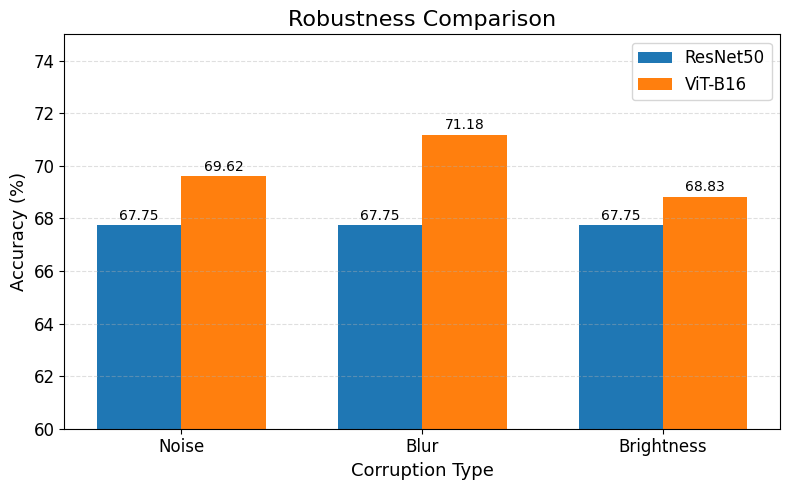

In [76]:
import matplotlib.pyplot as plt
import numpy as np

# Convert accuracy to percentage
resnet_acc = robustness_results["ResNet_Accuracy"] * 100
vit_acc = robustness_results["ViT_Accuracy"] * 100

conditions = robustness_results["Condition"]

x = np.arange(len(conditions))
width = 0.35

plt.figure(figsize=(8,5))

# ResNet bars
bars1 = plt.bar(
    x - width/2,
    resnet_acc,
    width,
    label="ResNet50"
)

# ViT bars
bars2 = plt.bar(
    x + width/2,
    vit_acc,
    width,
    label="ViT-B16"
)

# Add values above bars
for bar in bars1:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.2,
        f"{height:.2f}",
        ha="center",
        fontsize=10
    )

for bar in bars2:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.2,
        f"{height:.2f}",
        ha="center",
        fontsize=10
    )

plt.xticks(x, conditions, fontsize=12)
plt.yticks(fontsize=12)

plt.ylim(60, 75)

plt.xlabel("Corruption Type", fontsize=13)
plt.ylabel("Accuracy (%)", fontsize=13)
plt.title("Robustness Comparison", fontsize=16)

plt.legend(fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/robustness_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

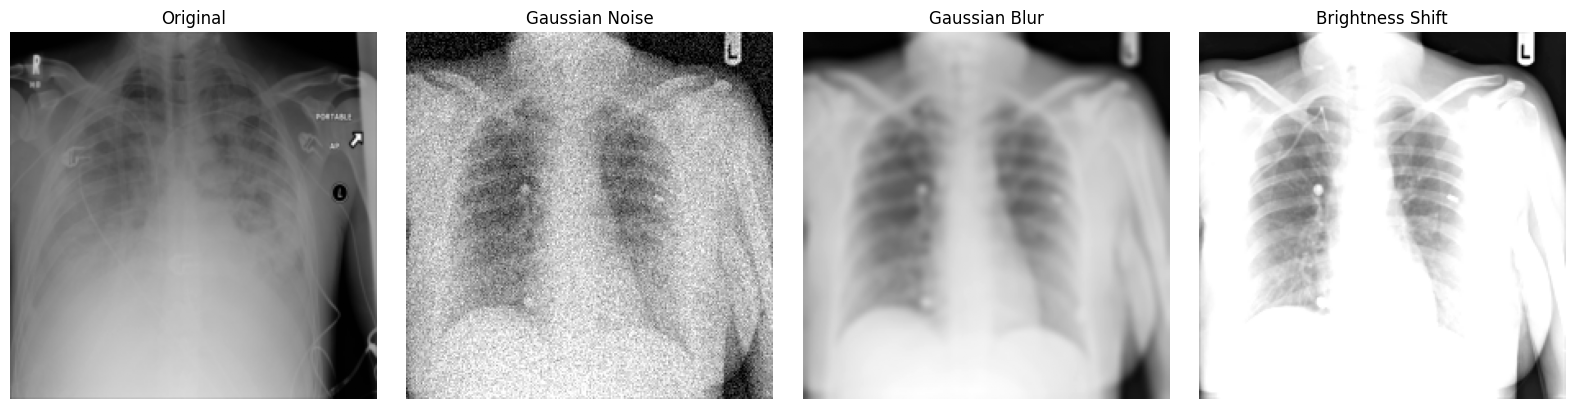

In [77]:
import matplotlib.pyplot as plt
import numpy as np

# Original image
original_img, _ = test_loader.dataset[0]

# Corrupted versions
noise_img, _ = noise_dataset[0]
blur_img, _ = blur_dataset[0]
brightness_img, _ = brightness_dataset[0]

imgs = [
    original_img,
    noise_img,
    blur_img,
    brightness_img
]

titles = [
    "Original",
    "Gaussian Noise",
    "Gaussian Blur",
    "Brightness Shift"
]

plt.figure(figsize=(16,4))

for i in range(4):

    img = imgs[i].permute(1,2,0).numpy()

    img = img * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406])


    img = img - img.min()
    img = img / (img.max() + 1e-8)

    img = np.clip(img,0,1)
    plt.subplot(1,4,i+1)

    plt.imshow(img[:,:,0], cmap="gray")

    plt.title(titles[i], fontsize=12)

    plt.axis("off")

plt.tight_layout()

plt.savefig(
    "/kaggle/working/corruption_examples.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [78]:
clean_resnet = 84.56  
clean_vit = 81.41         

drop_table = robustness_results.copy()

drop_table["ResNet_Drop"] = clean_resnet - (drop_table["ResNet_Accuracy"]*100)

drop_table["ViT_Drop"] = clean_vit - (drop_table["ViT_Accuracy"]*100)

drop_table


,Condition,ResNet_Accuracy,ViT_Accuracy,ResNet_Drop,ViT_Drop
0,Noise,0.677512,0.696197,16.808846,11.790303
1,Blur,0.677512,0.711805,16.808846,10.229521
2,Brightness,0.677512,0.688283,16.808846,12.581686


In [80]:
drop_table.to_csv(
    "/kaggle/working/robustness_drop.csv",
    index=False
)

In [81]:
noise_medium = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    AddGaussianNoise(std=0.06),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

noise_high = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    AddGaussianNoise(std=0.10),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [82]:
blur_medium = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.GaussianBlur(kernel_size=5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

blur_high = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.GaussianBlur(kernel_size=9),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [83]:
brightness_medium = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ColorJitter(brightness=0.4),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

brightness_high = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ColorJitter(brightness=0.6),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [84]:
noise_medium_dataset = RSNADataset(
    test_df,
    image_dir,
    noise_medium
)

noise_high_dataset = RSNADataset(
    test_df,
    image_dir,
    noise_high
)

blur_medium_dataset = RSNADataset(
    test_df,
    image_dir,
    blur_medium
)

blur_high_dataset = RSNADataset(
    test_df,
    image_dir,
    blur_high
)

brightness_medium_dataset = RSNADataset(
    test_df,
    image_dir,
    brightness_medium
)

brightness_high_dataset = RSNADataset(
    test_df,
    image_dir,
    brightness_high
)

In [85]:
from torch.utils.data import DataLoader

BATCH_SIZE = 64

noise_medium_loader = DataLoader(
    noise_medium_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

noise_high_loader = DataLoader(
    noise_high_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

blur_medium_loader = DataLoader(
    blur_medium_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

blur_high_loader = DataLoader(
    blur_high_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

brightness_medium_loader = DataLoader(
    brightness_medium_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

brightness_high_loader = DataLoader(
    brightness_high_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [88]:
import torch

def evaluate_accuracy(model, loader, device):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()

            total += labels.size(0)

    return correct / total
    acc = evaluate_accuracy(model, test_loader, device)
    print(acc)

In [91]:
import pandas as pd

severity_results = []

experiments = [

    ("Noise-Medium", noise_medium_loader),
    ("Noise-High", noise_high_loader),

    ("Blur-Medium", blur_medium_loader),
    ("Blur-High", blur_high_loader),

    ("Brightness-Medium", brightness_medium_loader),
    ("Brightness-High", brightness_high_loader)

]

for condition, loader in experiments:

    print(f"Running {condition}")

    resnet_acc = evaluate_accuracy(
        model,
        loader,
        device
    )

    vit_acc = evaluate_accuracy(
        vit_model,
        loader,
        device
    )

    severity_results.append({

        "Condition": condition,

        "ResNet50": round(resnet_acc*100,2),

        "ViT-B16": round(vit_acc*100,2)

    })

severity_results = pd.DataFrame(severity_results)

severity_results

Running Noise-Medium
Running Noise-High
Running Blur-Medium
Running Blur-High
Running Brightness-Medium
Running Brightness-High


,Condition,ResNet50,ViT-B16
0,Noise-Medium,67.75,70.76
1,Noise-High,67.75,69.11
2,Blur-Medium,67.75,71.33
3,Blur-High,67.75,71.36
4,Brightness-Medium,67.75,68.67
5,Brightness-High,67.75,68.12


In [94]:
clean_acc = evaluate_accuracy(
    model,
    test_loader,
    device
)

print(clean_acc)

0.8456157881588808


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.08956].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.031372547..1.0376734].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.031372547..1.08956].


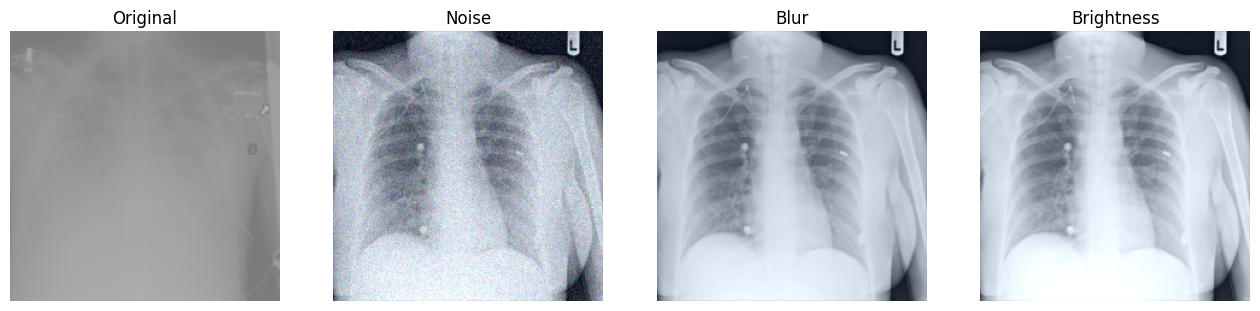

In [95]:
import matplotlib.pyplot as plt

idx = 0

orig, label = test_dataset[idx]
noise, _ = noise_medium_dataset[idx]
blur, _ = blur_high_dataset[idx]
bright, _ = brightness_high_dataset[idx]

fig, ax = plt.subplots(1,4, figsize=(16,4))

ax[0].imshow(orig.permute(1,2,0).numpy()*0.229+0.485)
ax[0].set_title("Original")

ax[1].imshow(noise.permute(1,2,0).numpy()*0.229+0.485)
ax[1].set_title("Noise")

ax[2].imshow(blur.permute(1,2,0).numpy()*0.229+0.485)
ax[2].set_title("Blur")

ax[3].imshow(bright.permute(1,2,0).numpy()*0.229+0.485)
ax[3].set_title("Brightness")

for a in ax:
    a.axis("off")

plt.show()

In [96]:
model.eval()

names = [
    ("Original", test_dataset),
    ("Noise", noise_medium_dataset),
    ("Blur", blur_high_dataset),
    ("Brightness", brightness_high_dataset)
]

idx = 10

for name, dataset in names:

    img, label = dataset[idx]

    img = img.unsqueeze(0).to(device)

    with torch.no_grad():

        out = model(img)

        prob = torch.softmax(out,1)

        pred = prob.argmax(1).item()

    print(name)

    print("Prediction :", pred)

    print("Probability:", prob.cpu().numpy())

    print()

Original
Prediction : 0
Probability: [[0.93565226 0.06434778]]

Noise
Prediction : 0
Probability: [[1. 0.]]

Blur
Prediction : 0
Probability: [[1. 0.]]

Brightness
Prediction : 0
Probability: [[1. 0.]]



In [97]:
noise_acc = evaluate_accuracy(
    model,
    noise_medium_loader,
    device
)

print(noise_acc)

0.6775115409980216


In [92]:
images, labels = next(iter(test_loader))

images = images.to(device)

model.eval()

with torch.no_grad():
    outputs = model(images)
    preds = outputs.argmax(1)

print("Labels:")
print(labels[:20])

print("Predictions:")
print(preds[:20].cpu())

Labels:
tensor([1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1])
Predictions:
tensor([1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1])


In [98]:

print(evaluate_accuracy(model, test_loader, device))


images, labels = next(iter(noise_medium_loader))
images = images.to(device)

model.eval()
with torch.no_grad():
    outputs = model(images)
    preds = outputs.argmax(1)

print("Batch accuracy:",
      (preds == labels.to(device)).float().mean().item())

0.8456157881588808
Batch accuracy: 0.703125


In [99]:
print(test_df["Target"].value_counts())

Target
0    3082
1    1467
Name: count, dtype: int64


In [100]:
print(len(test_df))

4549


In [101]:
images, labels = next(iter(blur_high_loader))
images = images.to(device)

model.eval()
with torch.no_grad():
    outputs = model(images)
    preds = outputs.argmax(1)

print("Blur batch accuracy:",
      (preds == labels.to(device)).float().mean().item())

Blur batch accuracy: 0.703125


In [105]:
images, labels = next(iter(brightness_high_loader))
images = images.to(device)

model.eval()
with torch.no_grad():
    outputs = model(images)
    preds = outputs.argmax(1)

print("Brightness batch accuracy:",
      (preds == labels.to(device)).float().mean().item())

Brightness batch accuracy: 0.703125


In [106]:
images, labels = next(iter(noise_high_loader))
images = images.to(device)

model.eval()
with torch.no_grad():
    outputs = model(images)
    preds = outputs.argmax(1)

print("noise batch accuracy:",
      (preds == labels.to(device)).float().mean().item())

noise batch accuracy: 0.703125


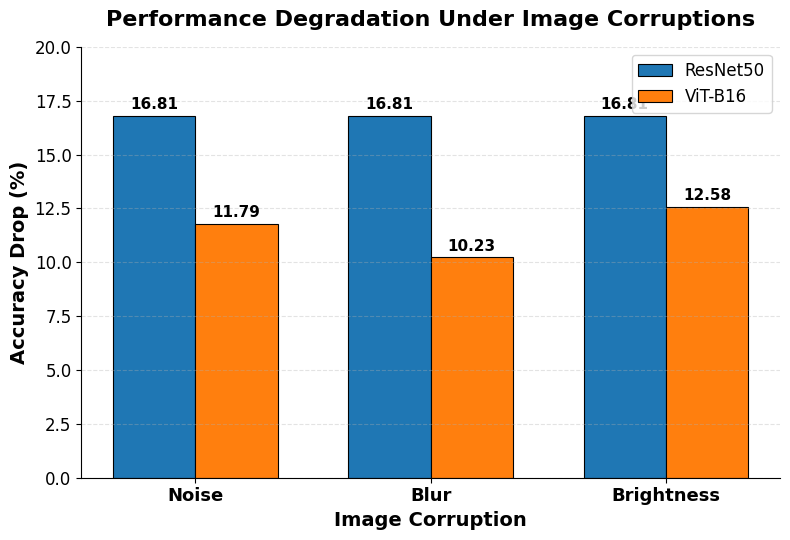

In [110]:
import matplotlib.pyplot as plt
import numpy as np

# Data
conditions = ["Noise", "Blur", "Brightness"]

resnet_drop = [16.81, 16.81, 16.81]
vit_drop = [11.79, 10.23, 12.58]

x = np.arange(len(conditions))
width = 0.35

plt.figure(figsize=(8,5.5))

bars1 = plt.bar(
    x - width/2,
    resnet_drop,
    width,
    color="#1f77b4",
    edgecolor="black",
    linewidth=0.8,
    label="ResNet50"
)

bars2 = plt.bar(
    x + width/2,
    vit_drop,
    width,
    color="#ff7f0e",
    edgecolor="black",
    linewidth=0.8,
    label="ViT-B16"
)

# Add value labels
for bar in bars1:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.15,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

for bar in bars2:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.15,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

# Formatting
plt.xticks(
    x,
    conditions,
    fontsize=13,
    fontweight="bold"
)

plt.yticks(fontsize=12)

plt.ylabel(
    "Accuracy Drop (%)",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(
    "Image Corruption",
    fontsize=14,
    fontweight="bold"
)

plt.title(
    "Performance Degradation Under Image Corruptions",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.ylim(0,20)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.35
)

# Remove top/right borders
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.legend(
    fontsize=12,
    frameon=True,
    loc="upper right"
)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/performance_drop_publication.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [111]:
import torch
import numpy as np

def get_predictions(model, loader, device):

    model.eval()

    preds = []
    labels = []

    with torch.no_grad():

        for images, target in loader:

            images = images.to(device)

            outputs = model(images)

            pred = outputs.argmax(1).cpu().numpy()

            preds.extend(pred)
            labels.extend(target.numpy())

    return np.array(preds), np.array(labels)


resnet_preds, labels = get_predictions(
    model,
    test_loader,
    device
)

vit_preds, _ = get_predictions(
    vit_model,
    test_loader,
    device
)

In [112]:
!pip install statsmodels

In [113]:
from statsmodels.stats.contingency_tables import mcnemar
import numpy as np

resnet_correct = (resnet_preds == labels)
vit_correct = (vit_preds == labels)

b = np.sum(resnet_correct & (~vit_correct))
c = np.sum((~resnet_correct) & vit_correct)

table = [[0, b],
         [c, 0]]

result = mcnemar(
    table,
    exact=False,
    correction=True
)

print("McNemar Statistic :", result.statistic)
print("P-value :", result.pvalue)

if result.pvalue < 0.05:
    print("Difference is statistically significant.")
else:
    print("Difference is NOT statistically significant.")

McNemar Statistic : 45.00243309002433
P-value : 1.9678978533717638e-11
Difference is statistically significant.


In [115]:
import math

def accuracy_confidence_interval(correct, total, confidence=0.95):

    p = correct / total

    z = 1.96          # 95% Confidence

    se = math.sqrt(
        p * (1 - p) / total
    )

    lower = p - z * se
    upper = p + z * se

    return (
        p * 100,
        lower * 100,
        upper * 100
    )

In [116]:
# Total test samples
N = len(labels)

# Correct predictions
resnet_correct = (resnet_preds == labels).sum()

vit_correct = (vit_preds == labels).sum()

print(resnet_correct)
print(vit_correct)

3385
3248


In [117]:
resnet_acc, resnet_low, resnet_high = accuracy_confidence_interval(
    resnet_correct,
    N
)

vit_acc, vit_low, vit_high = accuracy_confidence_interval(
    vit_correct,
    N
)

print(f"ResNet50 : {resnet_acc:.2f}% "
      f"(95% CI {resnet_low:.2f}-{resnet_high:.2f})")

print(f"ViT-B16 : {vit_acc:.2f}% "
      f"(95% CI {vit_low:.2f}-{vit_high:.2f})")

ResNet50 : 84.56% (95% CI 83.44-85.68)
ViT-B16 : 81.14% (95% CI 79.93-82.35)


In [118]:
import pandas as pd

statistics = pd.DataFrame({

    "Model":[
        "ResNet50",
        "ViT-B16"
    ],

    "Accuracy (%)":[
        round(resnet_acc,2),
        round(vit_acc,2)
    ],

    "95% CI":[
        f"{resnet_low:.2f}–{resnet_high:.2f}",
        f"{vit_low:.2f}–{vit_high:.2f}"
    ]

})

statistics

statistics.to_csv(
    "/kaggle/working/statistical_summary.csv",
    index=False
)

In [119]:
!pip install thop

In [121]:
from thop import profile
import torch

dummy = torch.randn(
    1,
    3,
    224,
    224
).to(device)

flops, params = profile(
    model,
    inputs=(dummy,)
)

print("Parameters:",
      params/1e6,
      "Million")

print("FLOPs:",
      flops/1e9,
      "GFLOPs")

[INFO] Register count_convNd() for <class 'torch.nn.modules.conv.Conv2d'>.
[INFO] Register count_normalization() for <class 'torch.nn.modules.batchnorm.BatchNorm2d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.activation.ReLU'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.pooling.MaxPool2d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.container.Sequential'>.
[INFO] Register count_adap_avgpool() for <class 'torch.nn.modules.pooling.AdaptiveAvgPool2d'>.
[INFO] Register count_linear() for <class 'torch.nn.modules.linear.Linear'>.
Parameters: 23.51213 Million
FLOPs: 4.131698688 GFLOPs


In [147]:
!pip install fvcore

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for fvcore: filename=fvcore-0.1.5.post20221221-py3-none-any.whl size=61397 sha256=a2a53a83a8314a7f2f0ad05f0d87a1cedc39e970e95524d3038ecd8382fe2351
  Stored in directory: /root/.cache/pip/wheels/ed/9f/a5/e4f5b27454ccd4596bd8b62432c7d6b1ca9fa22aef9d70a16a
  Created wheel for iopath: filename=iopath-0.1.10-py3-none-any.whl size=31527 sha256=557aebe60e862225dcf6722e7d3fee637232721dd187d6c8b2c5e74c13944c96
  Stored in directory: /root/.cache/pip/wheels/7c/96/04/4f5f31ff812f684f69f40cb1634357812220aac58d4698048c
Successfully built fvcore iopath


In [148]:
from fvcore.nn import FlopCountAnalysis

dummy = torch.randn(1, 3, 224, 224).to(device)

vit_model.eval()

flops = FlopCountAnalysis(vit_model, dummy)

print(f"ViT FLOPs: {flops.total()/1e9:.2f} GFLOPs")

Unsupported operator aten::mul encountered 49 time(s)
Unsupported operator aten::add encountered 25 time(s)
Unsupported operator aten::div encountered 12 time(s)
Unsupported operator aten::unflatten encountered 12 time(s)
Unsupported operator aten::scaled_dot_product_attention encountered 12 time(s)
Unsupported operator aten::gelu encountered 12 time(s)
The following submodules of the model were never called during the trace of the graph. They may be unused, or they were accessed by direct calls to .forward() or via other python methods. In the latter case they will have zeros for statistics, though their statistics will still contribute to their parent calling module.
encoder.layers.encoder_layer_0.self_attention.out_proj, encoder.layers.encoder_layer_1.self_attention.out_proj, encoder.layers.encoder_layer_10.self_attention.out_proj, encoder.layers.encoder_layer_11.self_attention.out_proj, encoder.layers.encoder_layer_2.self_attention.out_proj, encoder.layers.encoder_layer_3.self_atte

ViT FLOPs: 16.87 GFLOPs


In [149]:
import torch
import matplotlib.pyplot as plt

model.eval()

misclassified = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)

        preds = outputs.argmax(1)

        for i in range(len(labels)):

            if preds[i].cpu() != labels[i]:

                misclassified.append({

                    "image": images[i].cpu(),

                    "true": labels[i].item(),

                    "pred": preds[i].cpu().item(),

                    "confidence": probs[i].max().cpu().item()

                })

        if len(misclassified) >= 10:
            break

print("Misclassified images:", len(misclassified))

Misclassified images: 14


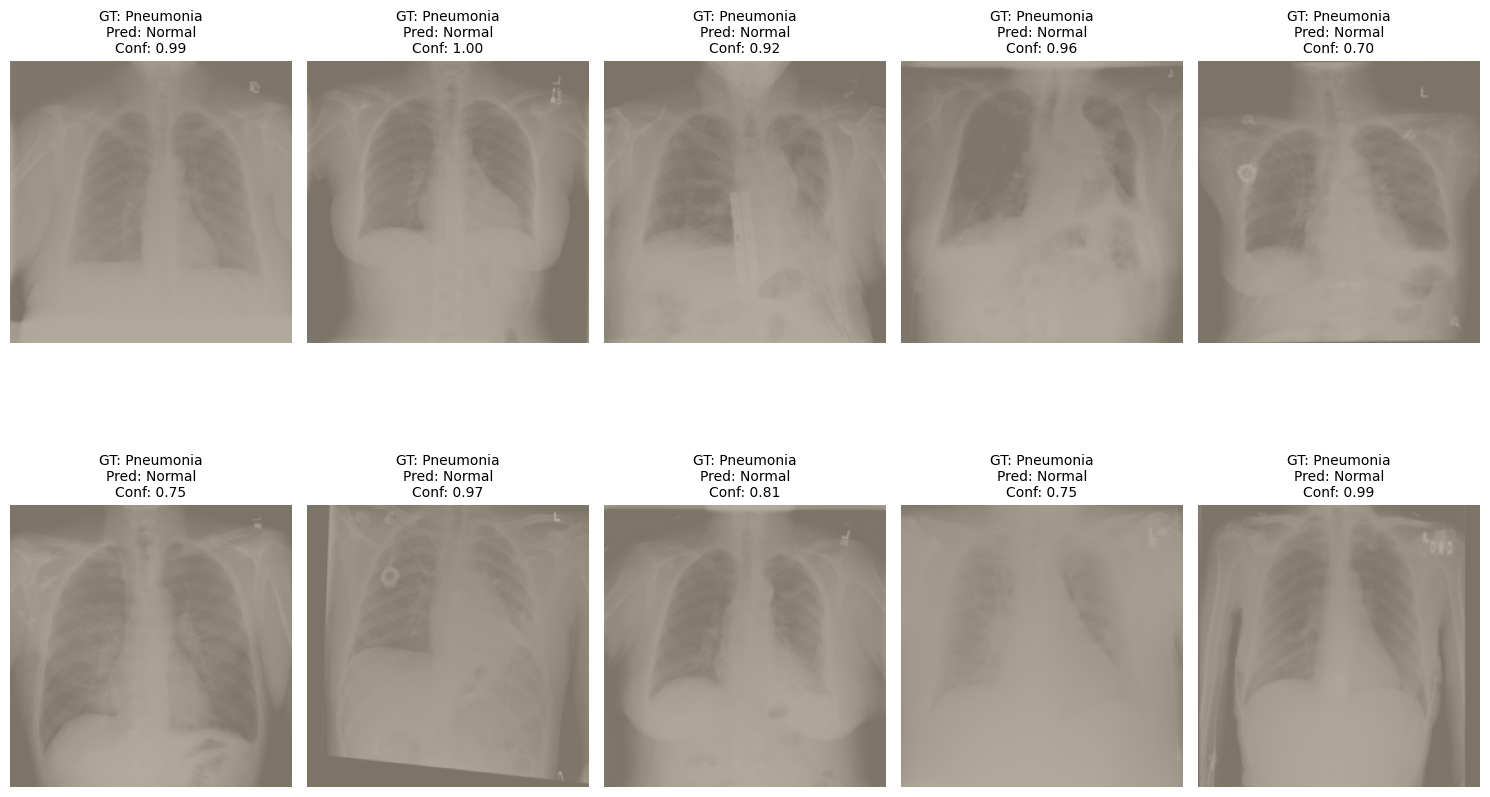

In [150]:
class_names = ["Normal", "Pneumonia"]

plt.figure(figsize=(15,10))

for i in range(min(10, len(misclassified))):

    img = misclassified[i]["image"]

    img = img.permute(1,2,0).numpy()

    mean = [0.485,0.456,0.406]
    std = [0.229,0.224,0.225]

    img = img * std + mean
    img = img.clip(0,1)

    plt.subplot(2,5,i+1)

    plt.imshow(img)

    plt.axis("off")

    plt.title(
        f"GT: {class_names[misclassified[i]['true']]}\n"
        f"Pred: {class_names[misclassified[i]['pred']]}\n"
        f"Conf: {misclassified[i]['confidence']:.2f}",
        fontsize=10
    )

plt.tight_layout()

plt.savefig(
    "/kaggle/working/error_analysis.png",
    dpi=600
)

plt.show()

In [178]:
import numpy as np
import matplotlib.pyplot as plt

from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image

In [179]:
resnet_target_layers = [model.layer4[-1]]

resnet_cam = GradCAMPlusPlus(
    model=model,
    target_layers=resnet_target_layers
)

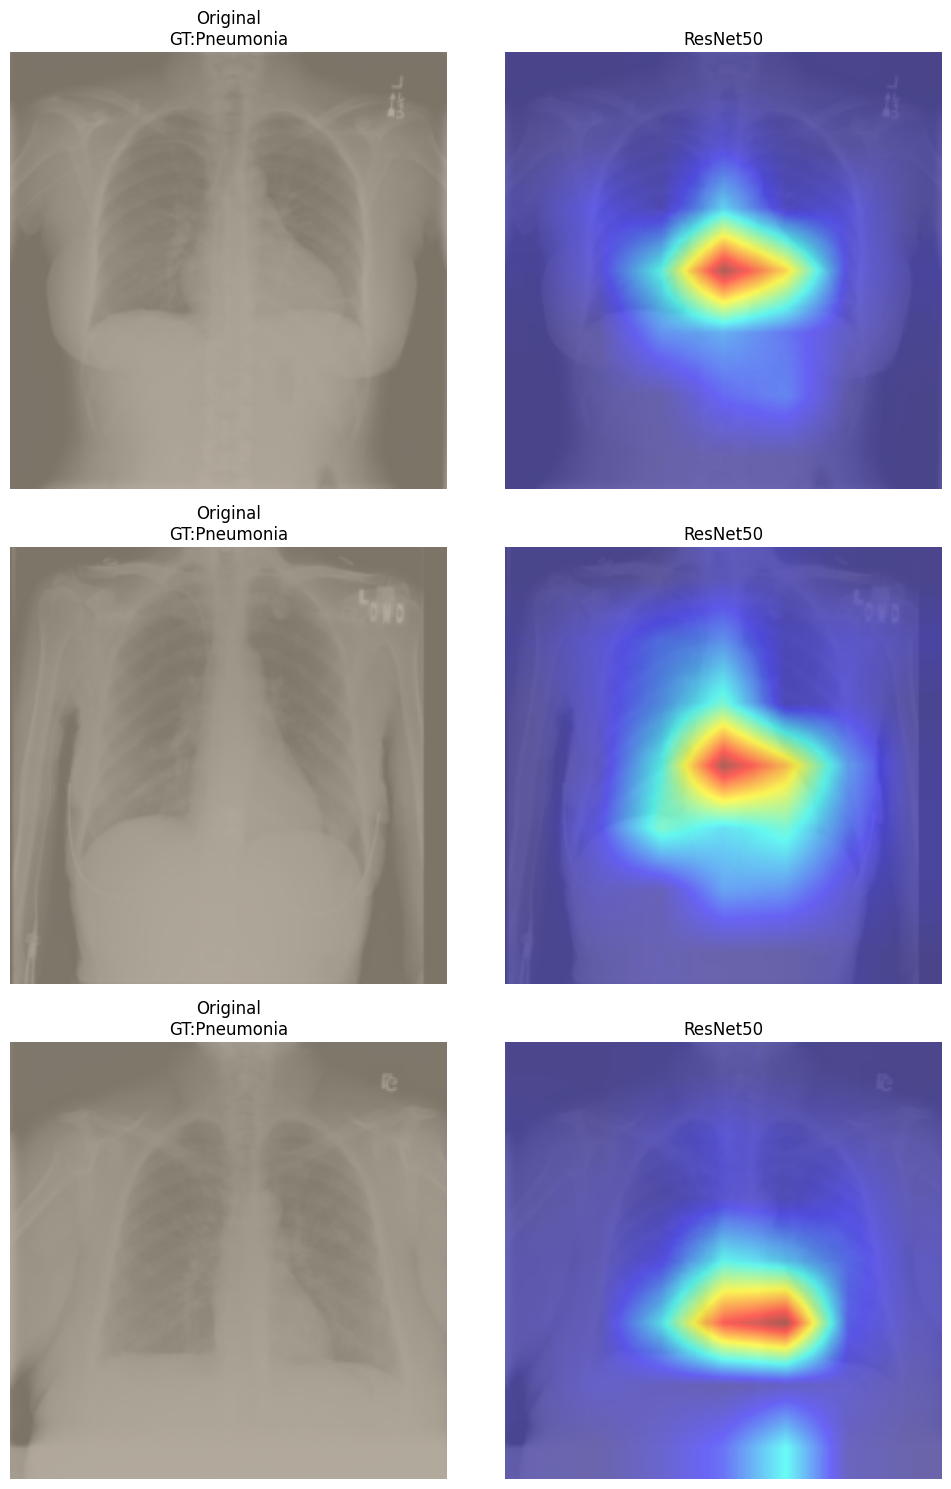

In [183]:
class_names = ["Normal", "Pneumonia"]

mean = np.array([0.485,0.456,0.406])
std = np.array([0.229,0.224,0.225])

plt.figure(figsize=(15,15))

for i in range(3):

    sample = misclassified[i]

    image_tensor = sample["image"].unsqueeze(0).to(device)

    
    # ResNet CAM


    resnet_gray = resnet_cam(
        input_tensor=image_tensor
    )[0]

    
    

    
    # Convert image
    

    rgb_img = sample["image"].permute(1,2,0).numpy()

    rgb_img = rgb_img * std + mean

    rgb_img = np.clip(rgb_img,0,1)

    resnet_vis = show_cam_on_image(
        rgb_img,
        resnet_gray,
        use_rgb=True
    )

    

    
    # Original
    

    plt.subplot(3,3,3*i+1)

    plt.imshow(rgb_img)

    plt.axis("off")

    plt.title(
        f"Original\nGT:{class_names[sample['true']]}"
    )

    
    # ResNet
    

    plt.subplot(3,3,3*i+2)

    plt.imshow(resnet_vis)

    plt.axis("off")

    plt.title("ResNet50")

    
plt.tight_layout()

plt.savefig(
    "/kaggle/working/resnet_vs_vit_gradcam.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()